In [13]:
import numpy as np
import subprocess
import random
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
config ={
  "trace_interval": 0.2,
  "scheduler": "DPP",
  "time_samples": 1,
  "ues": [
    {
      "id": 1,
      "fiveqi": "GBR_GAMING",
      "traffic_mbps": [8e+06],
      "gfbr_mbps":  [8e+06]
    },
    {
      "id": 2,
      "fiveqi": "GBR_GAMING",
      "traffic_mbps": [8e+06],
      "gfbr_mbps":  [0]
    },
     {
      "id": 3,
      "fiveqi": "GBR_GAMING",
      "traffic_mbps": [8e+06],
      "gfbr_mbps": [0]
    },
    {
      "id": 4,
      "fiveqi": "GBR_GAMING",
      "traffic_mbps": [8e+06],
      "gfbr_mbps": [8e+06]
    }
   
  ]
}

In [2]:
import json
import subprocess

CONFIG_FILE = "real_scenario.json"

# ===============================
# LOAD CONFIG
# ===============================

# with open(CONFIG_FILE, "r") as f:
#     config = json.load(f)

TRACE_INTERVAL = config["trace_interval"]
SCHEDULER = config["scheduler"]
TIME_SAMPLES = config["time_samples"]

ues = config["ues"]
NUM_UES = len(ues)

traffic_profiles = []
gbr_profiles = []
fiveqi_profiles = []

for ue in ues:
    # traffic = [x *1e6  for x in ue["traffic_mbps"]]  # convert Mbps → bps
    # gfbr = [x *1e6  for x in ue["gfbr_mbps"]]        # convert Mbps → bps

    traffic = [x   for x in ue["traffic_mbps"]]  # convert Mbps → bps
    gfbr = [x   for x in ue["gfbr_mbps"]]        # convert Mbps → bps

    traffic_profiles.append(",".join(f"{x:.0f}" for x in traffic))
    gbr_profiles.append(",".join(f"{x:.0f}" for x in gfbr))
    fiveqi_profiles.append(ue["fiveqi"])

traffic_str = "|".join(traffic_profiles)
gbr_str = "|".join(gbr_profiles)
fiveqi_str = "|".join(fiveqi_profiles)

# ===============================
# PRINT CONFIG SUMMARY
# ===============================

print("Launching simulation with:")
print(f"  UEs: {NUM_UES}")
print(f"  Scheduler: {SCHEDULER}")
print(f"  Trace interval: {TRACE_INTERVAL}s")
print()

for ue in ues:
    print(f"  UE {ue['id']}:")
    print(f"    5QI: {ue['fiveqi']}")
    print(f"    Traffic: {ue['traffic_mbps']} Mbps")
    print(f"    GFBR: {ue['gfbr_mbps']} Mbps")
    print()

# ===============================
# NS-3 RUN
# ===============================

# cmd = [
#     "./ns3", "run",
#     f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi "
#     f"--trafficProfile={traffic_str} "
#     f"--gbrProfile={gbr_str} "
#     f"--fiveQiProfiles={fiveqi_str} "
#     f"--traceInterval={TRACE_INTERVAL} "
#     f"--schedulerType={SCHEDULER} "
#     f"--enableOfdma=true "
#     f"--vrUeNum={NUM_UES} "
#     f"--arUeNum=0 "
#     f"--cgUeNum=0"
# ]

# subprocess.run(cmd)

NameError: name 'config' is not defined

In [46]:

# ===============================
# CONFIGURATION
# ===============================

NUM_UES = 8
TIME_SAMPLES = 200        # number of update intervals
TRACE_INTERVAL =   0.2     # seconds
SCHEDULER = "DPP"

# Allowed 5QI profiles (must match C++ mapping)
AVAILABLE_5QI = [
    "GBR_GAMING",
    "NGBR_LOW_LAT_EMBB",
    # "GBR_CONV_VIDEO"
]


# ===============================
# PROFILE GENERATION
# ===============================

def generate_profiles(num_ues, T):
    traffic_profiles = []
    gbr_profiles = []
    fiveqi_profiles = []

    for ue in range(num_ues):

        # --- Generate traffic demand (Mbps)
        demand = np.random.uniform(30, 30, T) *1e6

        demand[1] =0
        demand[3] =0
        # demand = 5e6

        # --- Generate forecast (GFBR)
        # Example: forecast with slight bias + noise
        # forecast = demand * np.random.uniform(0.9, 1.15)
        # forecast = demand * np.random.uniform(0.8, 0.8)
        # forecast = 4e6

        # --- Select 5QI per UE
        fiveqi = random.choice(AVAILABLE_5QI)

        if fiveqi == "GBR_GAMING" or fiveqi == "GBR_CONV_VIDEO":
            forecast = demand * np.random.uniform(0.1, 1.15)
            # forecast = demand * np.random.uniform(1, 1)
        else:
            forecast = np.zeros(T)  # NGBR has no guaranteed bitrate

        # --- Convert to string format
        traffic_profiles.append(",".join(f"{x:.2f}" for x in demand))
        gbr_profiles.append(",".join(f"{x:.2f}" for x in forecast))
        fiveqi_profiles.append(fiveqi)

    return traffic_profiles, gbr_profiles, fiveqi_profiles


In [50]:
traffic_profiles, gbr_profiles, fiveqi_profiles = \
    generate_profiles(NUM_UES, TIME_SAMPLES)

traffic_str = "|".join(traffic_profiles)
gbr_str = "|".join(gbr_profiles)
fiveqi_str = "|".join(fiveqi_profiles)

print("Launching simulation with:")
print(f"  UEs: {NUM_UES}")
print(f"  Scheduler: {SCHEDULER}")
print(f"  Trace interval: {TRACE_INTERVAL}s")
print(f"  5QI per UE: {fiveqi_profiles}")
print()

Launching simulation with:
  UEs: 8
  Scheduler: DPP
  Trace interval: 0.2s
  5QI per UE: ['GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'GBR_GAMING', 'GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'NGBR_LOW_LAT_EMBB']



In [52]:
print("Launching simulation with:")
print(f"  UEs: {NUM_UES}")
print(f"  Scheduler: {SCHEDULER}")
print(f"  Trace interval: {TRACE_INTERVAL}s")
print(f"  5QI per UE: {fiveqi_profiles}")

Launching simulation with:
  UEs: 8
  Scheduler: DPP
  Trace interval: 0.2s
  5QI per UE: ['GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'GBR_GAMING', 'GBR_GAMING', 'NGBR_LOW_LAT_EMBB', 'NGBR_LOW_LAT_EMBB']


In [17]:
traffic_str

'30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00|30000000.00,0.00,30000000.00,0.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00,30000000.00'

In [18]:
gbr_str

'33461193.04,0.00,33461193.04,0.00,33461193.04,33461193.04,33461193.04,33461193.04,33461193.04,33461193.04|31003515.71,0.00,31003515.71,0.00,31003515.71,31003515.71,31003515.71,31003515.71,31003515.71,31003515.71|0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00|30632400.98,0.00,30632400.98,0.00,30632400.98,30632400.98,30632400.98,30632400.98,30632400.98,30632400.98|27461192.62,0.00,27461192.62,0.00,27461192.62,27461192.62,27461192.62,27461192.62,27461192.62,27461192.62|28329314.08,0.00,28329314.08,0.00,28329314.08,28329314.08,28329314.08,28329314.08,28329314.08,28329314.08|0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00|34348723.96,0.00,34348723.96,0.00,34348723.96,34348723.96,34348723.96,34348723.96,34348723.96,34348723.96'

In [53]:
app_duration = 10000
# app_duration = 450000


In [3]:
CONFIG_FILE = "/home/sergi/5glena-lyapunov-mac-scheduler/predictions/scenario.json"

In [56]:
TRACE_INTERVAL = 0.2

In [ ]:


# ===============================
# NS-3 LAUNCHER
# ===============================

dppV = 0
bandwidth = 10e6
numerology = 1
txPower = 41
distance = 450
schedulerType = "Qos"
vrUeNum = 8
dppV = 0.0
enableOfdma = 'true'
configFile = CONFIG_FILE
app_duration = app_duration
unified_name= 'test_unified_0s_qos.csv'


# cmd = [
#     "./ns3", "run",
#     f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi  --enableOfdma=true --configFile={CONFIG_FILE} --appDuration={app_duration} --dppV={dppV}"
# ]
# cmd = [
#     "./ns3", "run",
#     f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi  --enableOfdma={enableOfdma} --configFile={CONFIG_FILE} --appDuration={app_duration} --dppV={dppV} \
#         --bandwidth={bandwidth} \
#         --numerology={numerology} \
#         --txPower={txPower} \
#         --distance={distance} \
#         --schedulerType={schedulerType} \
#         --unifiedName={unified_name} "
# ]


# cmd = [
#     "./ns3", "run",
#     f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi  --enableOfdma={enableOfdma} --configFile={CONFIG_FILE} --appDuration={app_duration} --dppV={dppV}"
# ]


# cmd = [
#     "./ns3", "run",
#     f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi --trafficProfile={traffic_str} --gbrProfile={gbr_str} --fiveQiProfiles={fiveqi_str} --traceInterval={TRACE_INTERVAL} --schedulerType={SCHEDULER} --enableOfdma=true --vrUeNum={NUM_UES} --appDuration={app_duration}"
# ]
cmd = [
    "./ns3", "run",
    f"cttc-nr-traffic-3gpp-xr-qos-sched_sergi  --enableOfdma={enableOfdma}  --trafficProfile={traffic_str} --gbrProfile={gbr_str} --fiveQiProfiles={fiveqi_str} --traceInterval={TRACE_INTERVAL} --appDuration={app_duration} --dppV={dppV} \
        --bandwidth={bandwidth} \
        --numerology={numerology} \
        --txPower={txPower} \
        --distance={distance} \
        --schedulerType={schedulerType} \
        --unifiedName={unified_name}\
        --vrUeNum={vrUeNum}"
]


subprocess.run(cmd)
# subprocess.run(cmd,stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)







Scheduler: ns3::NrMacSchedulerOfdmaQos
[APP CREATED] UE index=0 ptr=0x5576edfee690
[APP CREATED] UE index=1 ptr=0x5576edff12b0
[APP CREATED] UE index=2 ptr=0x5576edff2dc0
[APP CREATED] UE index=3 ptr=0x5576edff48e0
[APP CREATED] UE index=4 ptr=0x5576edff6420
[APP CREATED] UE index=5 ptr=0x5576ee0db170
[APP CREATED] UE index=6 ptr=0x5576ee0dccb0
[APP CREATED] UE index=7 ptr=0x5576ee0de7b0
[CTX CREATED] UE 0 traffic[0]=30000000 ptr=0x5576edfee690
[CTX CREATED] UE 1 traffic[0]=30000000 ptr=0x5576edff12b0
[CTX CREATED] UE 2 traffic[0]=30000000 ptr=0x5576edff2dc0
[CTX CREATED] UE 3 traffic[0]=30000000 ptr=0x5576edff48e0
[CTX CREATED] UE 4 traffic[0]=30000000 ptr=0x5576edff6420
[CTX CREATED] UE 5 traffic[0]=30000000 ptr=0x5576ee0db170
[CTX CREATED] UE 6 traffic[0]=30000000 ptr=0x5576ee0dccb0
[CTX CREATED] UE 7 traffic[0]=30000000 ptr=0x5576ee0de7b0
videoPtrs size = 8
allVideoPtrs size = 8
trafficProfile size = 8
gbrProfile size = 8
dynamicUes size = 8


In [143]:

df = pd.read_csv("throughput_per_ue.csv")

In [144]:
df

,Time,UE0,UE1,UE2,UE3,UE4,UE5,UE6,UE7
0,1,1.10496,0,0,10.27700,6.08549,0,3.96646,0
1,2,6.36054,0,0,12.72170,9.74104,0,8.33442,0
2,3,6.08430,0,0,7.58510,11.01410,0,12.95260,0
3,4,9.31542,0,0,2.36371,19.17170,0,6.35439,0
4,5,15.02120,0,0,0.00000,22.17760,0,0.00000,0
5,6,0.00000,0,0,0.00000,5.07954,0,31.68580,0
6,7,0.00000,0,0,0.00000,15.58660,0,21.29720,0
7,8,0.00000,0,0,0.00000,11.85900,0,25.78680,0
8,9,0.00000,0,0,0.00000,17.15600,0,19.64760,0
9,10,27.79170,0,0,0.00000,4.68057,0,4.72388,0


In [145]:
import pandas as pd
import matplotlib.pyplot as plt

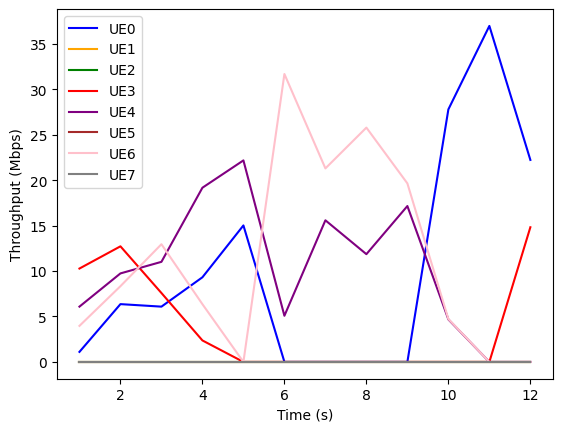

In [146]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']


df = pd.read_csv("throughput_per_ue.csv")

for i, col in enumerate(df.columns[1:]):
    plt.plot(df["Time"], df[col], label=col, color=colors[i])

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Throughput (Mbps)")
plt.show()

In [46]:
df.shape

(61, 9)

In [48]:
df_ue4 = df[["Time", "UE4"]]

In [49]:
df_ue4.mean()

Time    227.000000
UE4       0.895638
dtype: float64

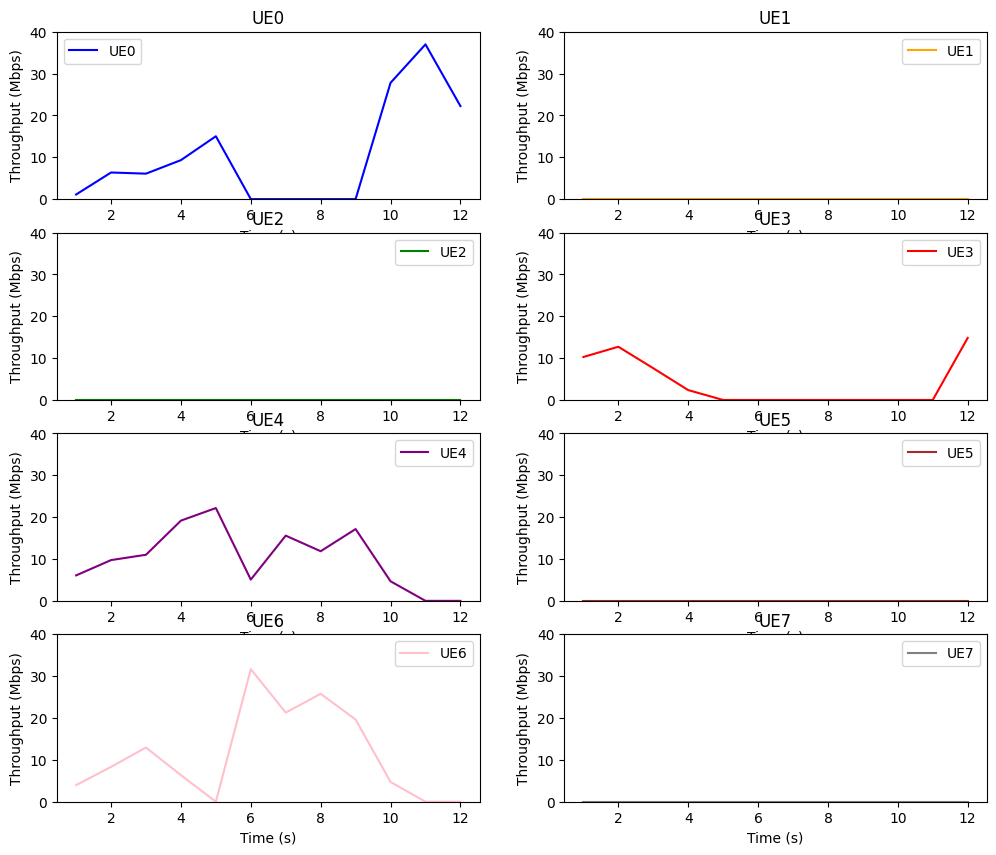

In [147]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("throughput_per_ue.csv")
fig, ax = plt.subplots(4, 2, figsize=(12, 10))
for i, col in enumerate(df.columns[1:]):
    # plt.figure()
    # plt.plot(df["Time"], df[col], label=col, color=colors[i])

    # plt.legend()
    # plt.xlabel("Time (s)")
    # plt.ylabel("Throughput (Mbps)")
    # plt.show()

    ax = ax.flatten()
    ax[i].plot(df["Time"], df[col], label=col, color=colors[i])
    ax[i].set_title(col)
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Throughput (Mbps)")
    ax[i].set_ylim(0,40)
    ax[i].legend()



In [14]:
df_rnti = df[df["RNTI"] == 7]

KeyError: 'RNTI'

In [15]:
df_rnti

NameError: name 'df_rnti' is not defined

In [54]:
df_rnti = df[df["RNTI"] == 8]

In [64]:
df_rnti.iloc[200,:]

Time(s)          400.4000
RNTI               8.0000
Traffic(Mbps)      0.0100
GFBR(Mbps)        47.1446
Name: 1600, dtype: float64

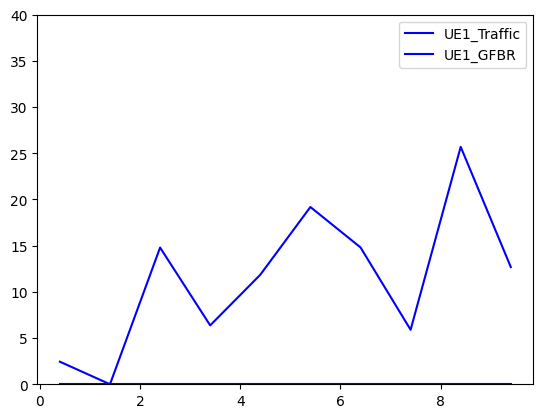

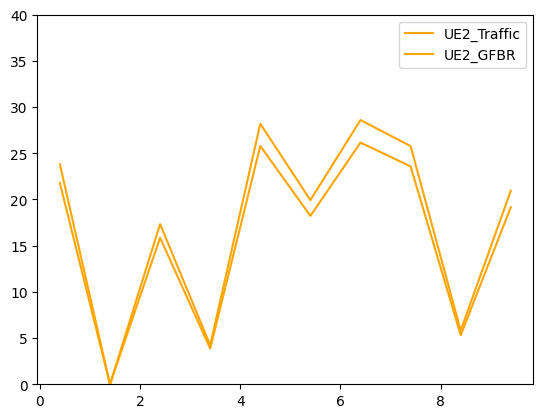

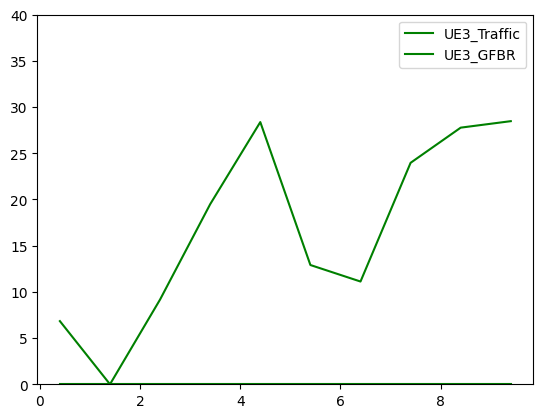

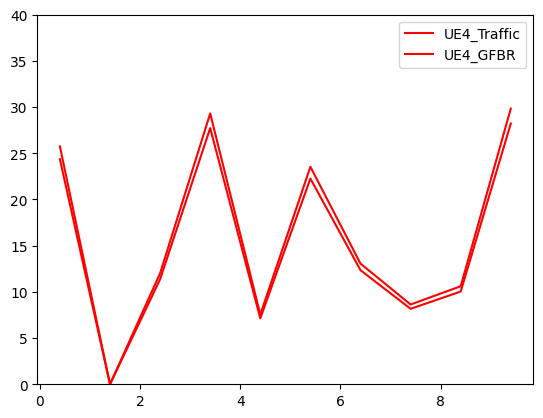

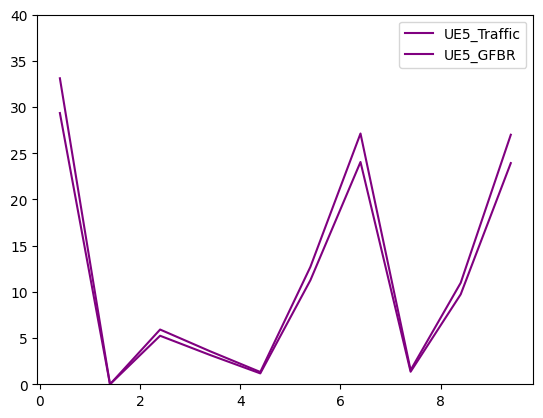

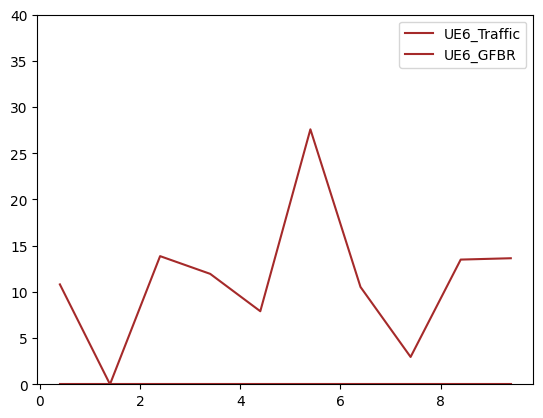

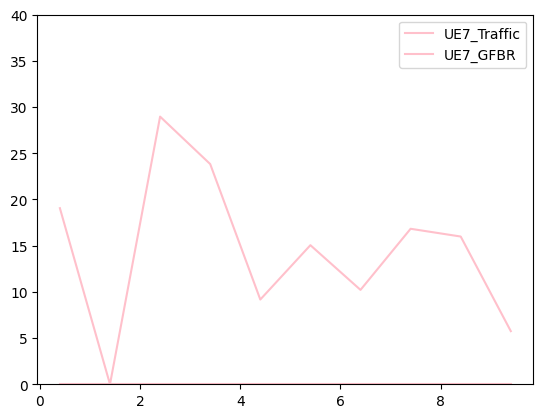

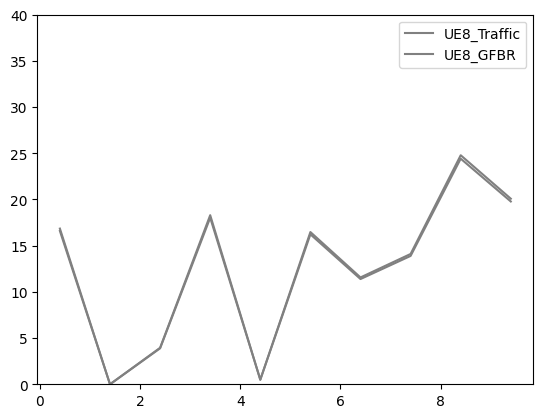

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("debug_updates.csv",sep="\t")
RNTIS=[1,2,3,4,5,6,7,8]
# RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    plt.figure()
    plt.plot(df_rnti["Time(s)"], df_rnti['Traffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i])
    plt.plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    plt.ylim(0,40)
    plt.legend()
    

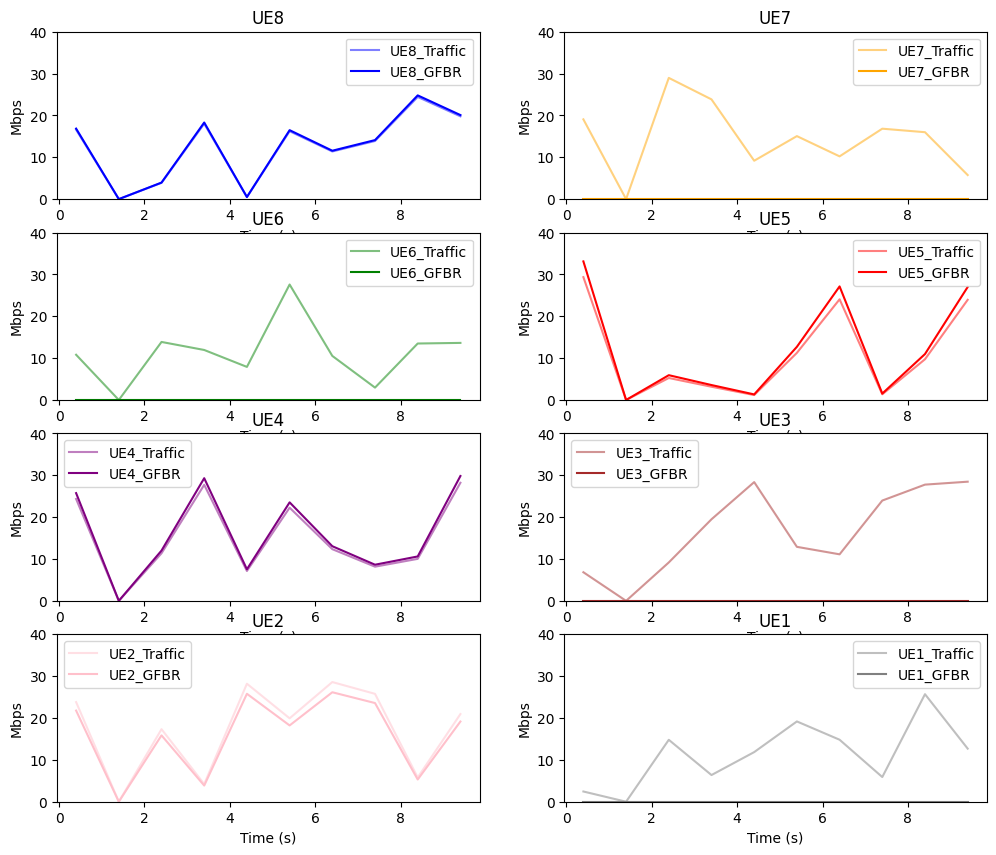

In [149]:

df = pd.read_csv("debug_updates.csv",sep="\t")
# RNTIS=[1,2,3,4,5,6,7,8]
RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
fig, ax = plt.subplots(4, 2, figsize=(12, 10))
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    ax = ax.flatten()
    ax[i].plot(df_rnti["Time(s)"], df_rnti['Traffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i],alpha=0.5)
    ax[i].plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    ax[i].set_title(f"UE{rnti}")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Mbps")
    ax[i].set_ylim(0,40)
    ax[i].legend()

In [124]:
throughput_df

,Time,UE0,UE1,UE2,UE3,UE4,UE5,UE6,UE7
0,0.2,0.00000,0,0,0.00000,0.00000,0,0.00000,0
1,0.4,0.00000,0,0,0.00000,0.00000,0,0.00000,0
2,0.6,1.38460,0,0,17.12060,10.14540,0,5.94712,0
3,0.8,9.66856,0,0,9.78748,8.12116,0,7.94172,0
4,1.0,4.15028,0,0,5.51232,12.83920,0,17.13200,0
...,...,...,...,...,...,...,...,...,...
56,11.4,4.94472,0,0,11.97000,16.46280,0,5.22876,0
57,11.6,4.94544,0,0,11.96670,14.10220,0,5.24432,0
58,11.8,6.58716,0,0,11.96140,14.12570,0,3.49112,0
59,12.0,4.93944,0,0,11.96830,16.47100,0,5.24240,0


In [128]:
df

,Time(s),RNTI,Traffic(Mbps),GFBR(Mbps)
0,0.4,8,16.5960,16.8488
1,0.4,7,19.0590,0.0000
2,0.4,6,10.8091,0.0000
3,0.4,5,29.3558,33.1164
4,0.4,4,24.3510,25.7456
...,...,...,...,...
75,2.2,5,23.9386,27.0053
76,2.2,4,28.2188,29.8348
77,2.2,3,28.4759,0.0000
78,2.2,2,20.9476,19.1617


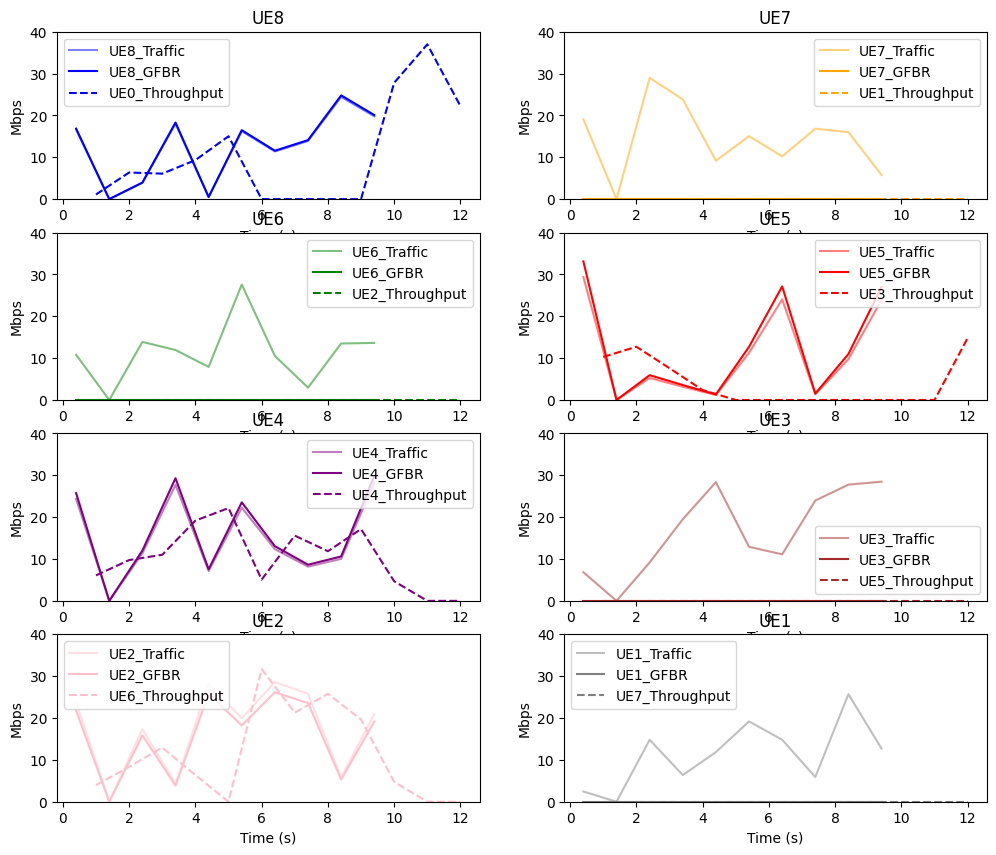

In [160]:

df = pd.read_csv("debug_updates.csv",sep="\t")
throughput_df = pd.read_csv("throughput_per_ue.csv")

# RNTIS=[1,2,3,4,5,6,7,8]
RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
fig, ax = plt.subplots(4, 2, figsize=(12, 10))
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    ax = ax.flatten()
    ax[i].plot(df_rnti["Time(s)"], df_rnti['Traffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i],alpha=0.5)
    ax[i].plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    ax[i].plot(throughput_df["Time"], throughput_df[f"UE{i}"], label=f"UE{i}_Throughput", color=colors[i], linestyle='--')
    ax[i].set_title(f"UE{rnti}")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Mbps")
    ax[i].set_ylim(0,40)
    ax[i].legend()

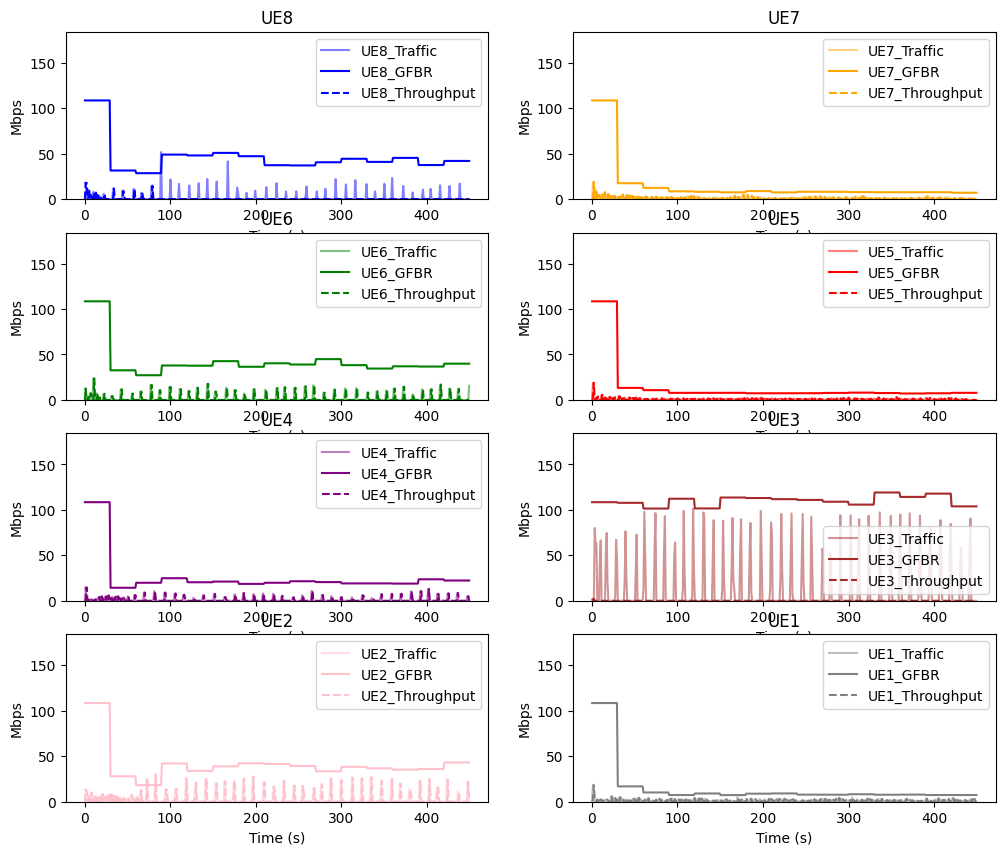

In [50]:
df = pd.read_csv('unified_stats.csv')
# RNTIS=[1,2,3,4,5,6,7,8]
RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
fig, ax = plt.subplots(4, 2, figsize=(12, 10))
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    ax = ax.flatten()
    ax[i].plot(df_rnti["Time(s)"], df_rnti['TargetTraffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i],alpha=0.5)
    ax[i].plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    ax[i].plot(df_rnti["Time(s)"], df_rnti['MeasuredThroughput(Mbps)'], label=f"UE{rnti}_Throughput", color=colors[i], linestyle='--')
    ax[i].set_title(f"UE{rnti}")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Mbps")
    ax[i].set_ylim(0,184)
    ax[i].legend()

In [56]:
df

,Time(s),RNTI,TargetTraffic(Mbps),GFBR(Mbps),MeasuredThroughput(Mbps)
0,0.4,8,17.503800,108.46400,0.000000
1,0.4,7,1.222920,108.46400,0.000000
2,0.4,6,12.321700,108.46400,0.000000
3,0.4,5,4.366140,108.46400,0.000000
4,0.4,4,0.413004,108.46400,0.000000
...,...,...,...,...,...
3595,449.4,5,0.000000,7.84712,0.000488
3596,449.4,4,0.000000,22.36000,0.000480
3597,449.4,3,0.000000,103.87300,0.000000
3598,449.4,2,0.000000,43.11830,0.369312


In [61]:
df_rnti['MeasuredThroughput(Mbps)']

0        0.000000
8       17.793800
16      18.062300
24       1.774670
32       0.040536
          ...    
3560     0.000000
3568     0.000000
3576     0.000000
3584     0.000000
3592     0.000000
Name: MeasuredThroughput(Mbps), Length: 450, dtype: float64

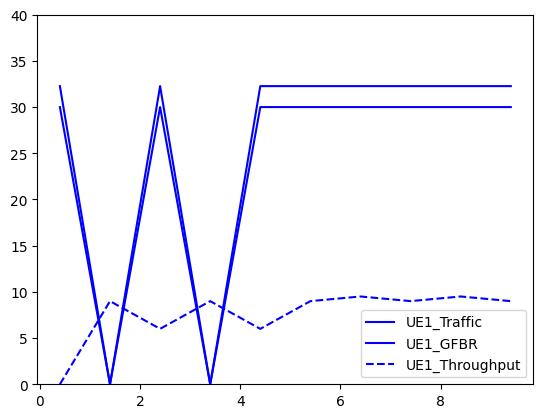

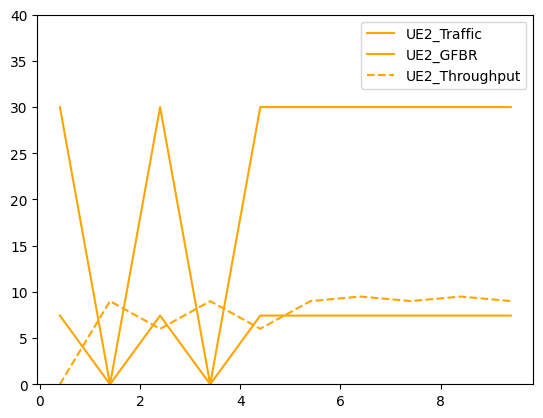

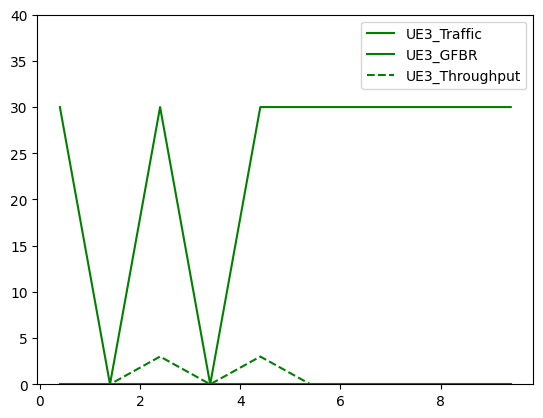

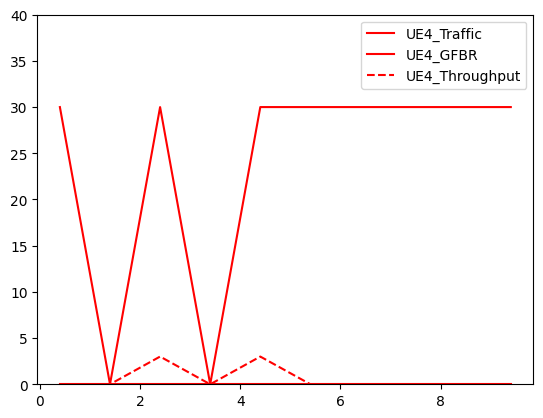

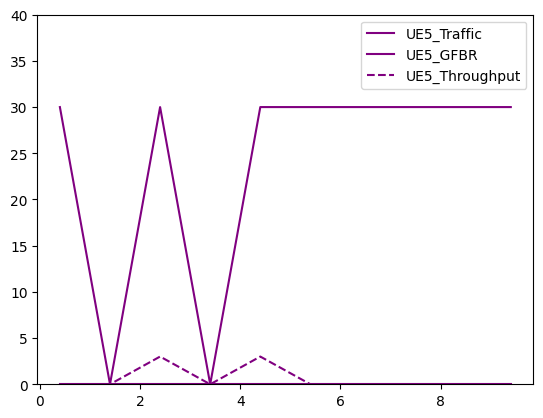

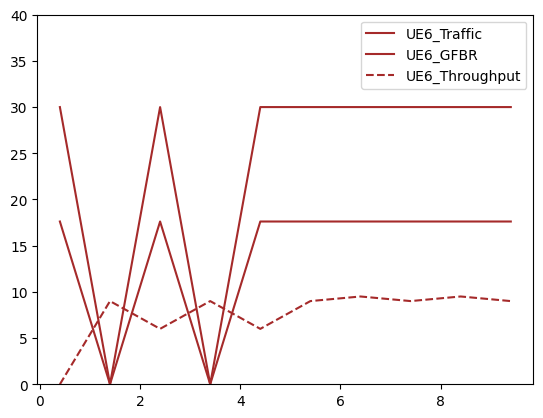

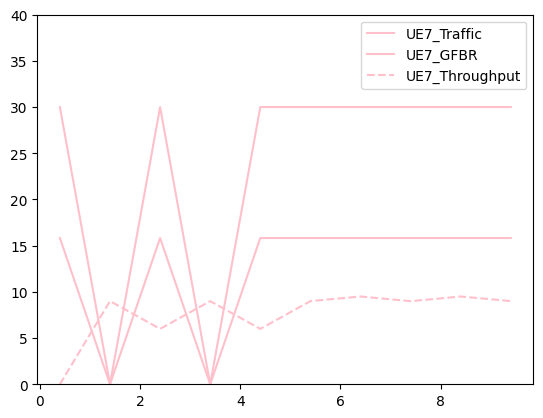

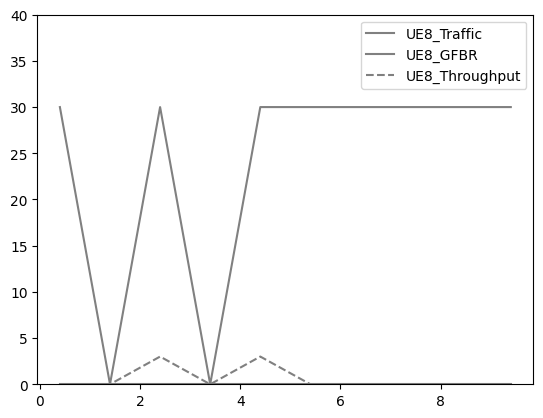

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

df = pd.read_csv("test_unified_0s_qos.csv")
RNTIS=[1,2,3,4,5,6,7,8]
# RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    
    
    plt.figure()
    plt.plot(df_rnti["Time(s)"], df_rnti['TargetTraffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i])
    plt.plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    plt.plot(df_rnti["Time(s)"], df_rnti['MeasuredThroughput(Mbps)'], label=f"UE{rnti}_Throughput", color=colors[i], linestyle='--')
    plt.ylim(0,40)
    plt.legend()

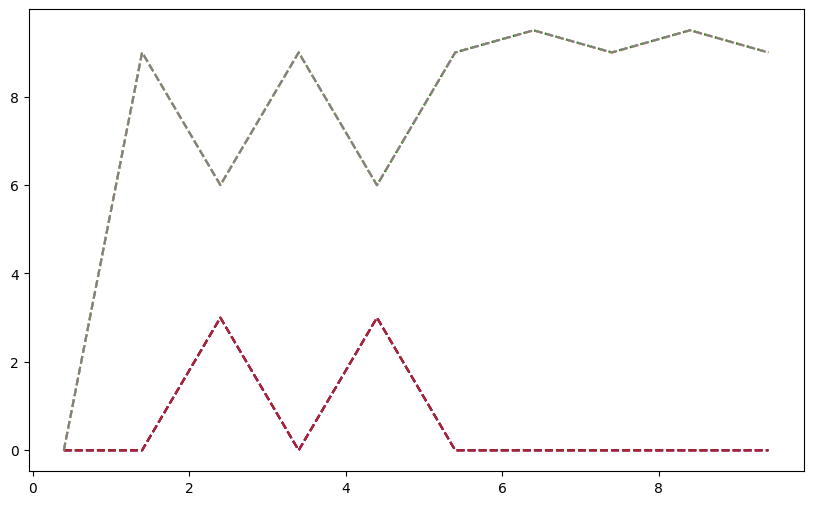

In [45]:
df = pd.read_csv('test_unified_0s_qos.csv')
# RNTIS=[1,2,3,4,5,6,7,8]
RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
plt.figure(figsize=(10,6))
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    plt.plot(df_rnti["Time(s)"], df_rnti['MeasuredThroughput(Mbps)'], label=f"UE{rnti}_Throughput", color=colors[i], linestyle='--')

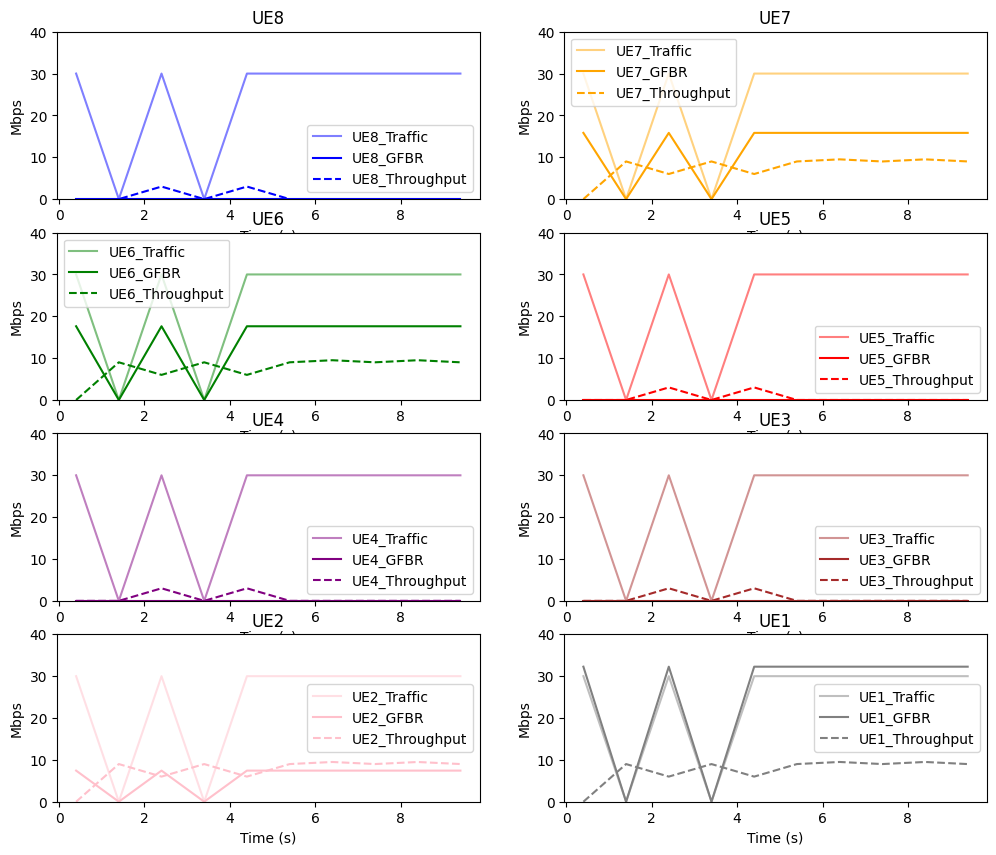

In [41]:
df = pd.read_csv('test_unified_0s_qos.csv')
# RNTIS=[1,2,3,4,5,6,7,8]
RNTIS=[8,7,6,5,4,3,2,1]
# RNTIS=[1]
fig, ax = plt.subplots(4, 2, figsize=(12, 10))
for i, rnti in enumerate(RNTIS):
    df_rnti = df[df["RNTI"] == rnti]
    ax = ax.flatten()
    ax[i].plot(df_rnti["Time(s)"], df_rnti['TargetTraffic(Mbps)'], label=f"UE{rnti}_Traffic", color=colors[i],alpha=0.5)
    ax[i].plot(df_rnti["Time(s)"], df_rnti['GFBR(Mbps)'], label=f"UE{rnti}_GFBR", color=colors[i])
    ax[i].plot(df_rnti["Time(s)"], df_rnti['MeasuredThroughput(Mbps)'], label=f"UE{rnti}_Throughput", color=colors[i], linestyle='--')
    ax[i].set_title(f"UE{rnti}")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Mbps")
    ax[i].set_ylim(0,40)
    ax[i].legend()

In [155]:
df

,Time(s),RNTI,TargetTraffic(Mbps),GFBR(Mbps),MeasuredThroughput(Mbps)
0,0.4,8,16.5960,16.8488,0.0000
1,0.4,7,19.0590,0.0000,0.0000
2,0.4,6,10.8091,0.0000,0.0000
3,0.4,5,29.3558,33.1164,0.0000
4,0.4,4,24.3510,25.7456,0.0000
...,...,...,...,...,...
75,9.4,5,23.9386,27.0053,0.0000
76,9.4,4,28.2188,29.8348,17.3117
77,9.4,3,28.4759,0.0000,0.0000
78,9.4,2,20.9476,19.1617,14.3606
